In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('E:/CIENCIA DE DATOS E IA/2-SEGUNDO AÑO\SEGUNDO CUATRIMESTRE/2- LABORATORIO DE MINERIA Y DATOS/Proyecto_AndesLink/data/churn_sintetico.csv')
print(df.head())

   tenure_months  monthly_charge  total_charges  support_tickets  \
0              7           58.23         326.50                2   
1             56           56.75        3154.21                0   
2             48           78.84        3864.31                3   
3             32           79.74        2511.40                0   
4             32           55.37        1735.51                3   

   late_payments  avg_monthly_usage_gb contract_type payment_method  \
0              1                 81.83       mensual  transferencia   
1              2                 96.52         anual         debito   
2              2                 93.60       bianual       efectivo   
3              0                 28.95       bianual         debito   
4              0                126.90         anual       efectivo   

  internet_service  has_streaming  has_security_pack  num_products  region  \
0            cable              0                  1             3  centro   
1       

In [10]:
df.shape 

(5000, 16)

In [11]:
df.isnull().sum()

tenure_months           0
monthly_charge          0
total_charges           0
support_tickets         0
late_payments           0
avg_monthly_usage_gb    0
contract_type           0
payment_method          0
internet_service        0
has_streaming           0
has_security_pack       0
num_products            0
region                  0
customer_age            0
is_promo                0
churn                   0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

C:\Users\resqu\AppData\Local\Temp\ipykernel_17572\1228897993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churn', palette='viridis')


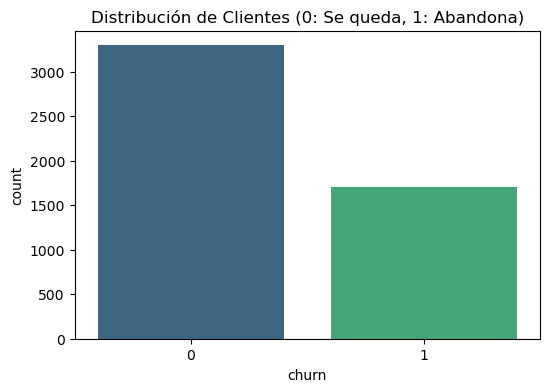

In [13]:
#1 Visualizar la distribución de Churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churn', palette='viridis')
plt.title('Distribución de Clientes (0: Se queda, 1: Abandona)')
plt.show()

In [14]:
#Distribución de Clientes (Gráfico de Barras)

# Este gráfico mide el desequilibrio de clases en el dataset.

# Donde la gran mayoría de tus clientes se mantienen (0), pero tenemos una cantidad significativa de abandonos (1).

# Interpretación: Visualmente, parece que el churn representa aproximadamente un 30-35% de la base total.

# Para entrenar un modelo de Machine Learning más adelante, este "desbalance" es importante; 
# si el grupo 1 fuera mucho más pequeño, tendrías que usar técnicas especiales (como sobremuestreo) 
# para que el modelo aprenda bien a identificar a los que se van.

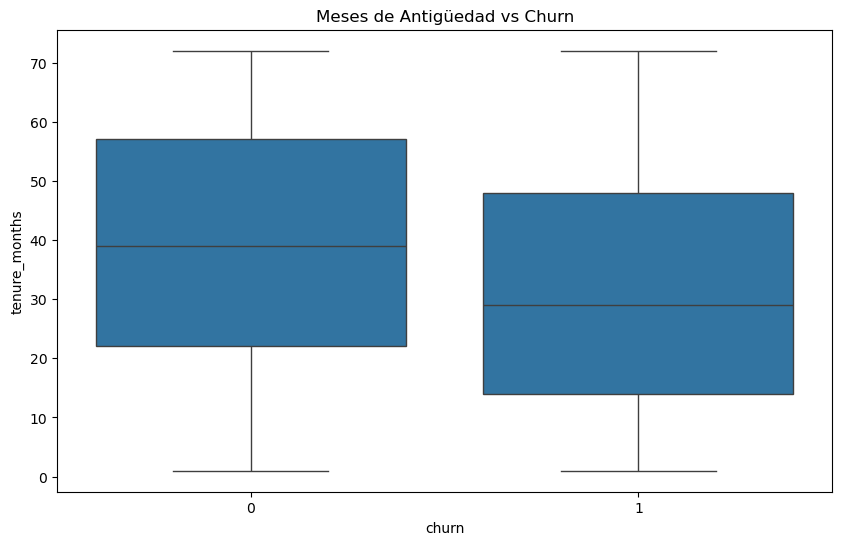

In [15]:
#2 Relación: Antigüedad vs Churn (Hipótesis: ¿los nuevos se van más?)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='churn', y='tenure_months')
plt.title('Meses de Antigüedad vs Churn')
plt.show()

In [16]:
# Meses de Antigüedad vs. Churn (Boxplot)

#Aquí comparamos la "lealtad" en tiempo. El boxplot muestra la mediana (la línea negra central) y la dispersión del 50% de los datos (la caja azul).

# Osea los clientes que se quedan (0) tienen una mediana de antigüedad notablemente más alta (cerca de los 40 meses).
# que los que se van (1) (cuya mediana está cerca de los 30 meses).

# La hipótesis de que "los nuevos se van más" parece ser correcta. 
# La caja del grupo 1 está más abajo en el eje Y, lo que indica que el riesgo de abandono es mayor durante los primeros dos años y medio de contrato.

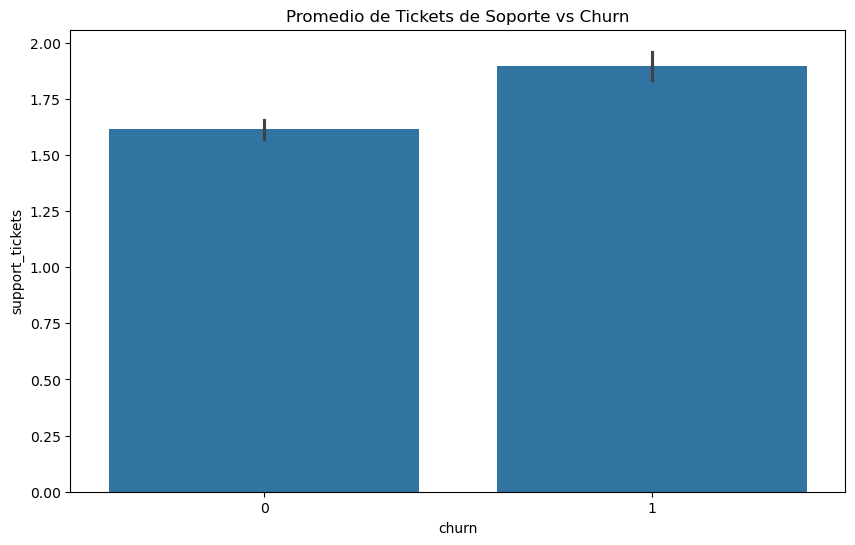

In [17]:
#3 Relación: Tickets de Soporte vs Churn
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='churn', y='support_tickets')
plt.title('Promedio de Tickets de Soporte vs Churn')
plt.show()

In [18]:
# Promedio de Tickets de Soporte vs. Churn (Barplot con error).

# Este gráfico muestra la relación entre la frustración técnica/administrativa y la salida del cliente.

# Existe una correlación clara. Los clientes que abandonan generan, en promedio, más tickets de soporte (cerca de 1.9) que los que se quedan (aprox. 1.6).

# La fricción en el servicio es un "trigger" (disparador) del abandono.
# Las pequeñas líneas negras arriba de las barras (barras de error) son cortas,B
# lo que significa que esta diferencia es estadísticamente significativa y no es fruto del azar.

In [19]:
# Estrategia:

# Tenemos un problema de retención concentrado en los clientes más nuevos (menos de 30 meses). 
# y aquellos que experimentan problemas técnicos recurrentes (reflejado en el mayor volumen de tickets). 
# Para bajar el churn, deberíamos enfocarnos en mejorar la experiencia de soporte.
# Y crear planes de fidelización para los clientes que llevan menos de dos años con nosotros. 

In [ ]:
# Conectamos con DagsHub
import dagshub
dagshub.init(repo_owner='JuanManuelResquin84', repo_name='Proyecto_AndesLink', mlflow=True)

import mlflow
with mlflow.start_run():
  mlflow.log_param('parameter name', 'value')
  mlflow.log_metric('metric name', 1)

Initialized MLflow to track repo "JuanManuelResquin84/Proyecto_AndesLink"

Repository JuanManuelResquin84/Proyecto_AndesLink initialized!

🏃 View run serious-dog-241 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/1c12beea96e14d89abbdfcaffae17ee8
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [22]:
# Preparamos los datos para el entrenamiento
import pandas as pd
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#1 Preparación de Datos (Copia y Limpieza)
df_ml = df.copy()

#2 Encoding
# Usamos One-Hot Encoding para las características (X)
# Esto crea columnas de 0 y 1 para categorías como 'plan_internet' o 'genero'
X = pd.get_dummies(df_ml.drop('churn', axis=1), drop_first=True)

#2 Usamos LabelEncoder solo para la variable objetivo (y)
le = LabelEncoder()
y = le.fit_transform(df_ml['churn'])

#3 División del Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Entrenamiento y Tracking con MLflow
with mlflow.start_run(run_name="RandomForest_OneHot_v1"):
    # Configuramos el modelo
    n_est = 100
    max_d = 5
    model = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=42)
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos y evaluamos
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Loggeamos todo a DagsHub
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("encoding_type", "OneHot")
    mlflow.log_metric("accuracy", accuracy)
    
    print(f"Entrenamiento terminado. Accuracy: {accuracy:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))